🔷 Dimensionality Reduction using PCA
🔷 Data Visualization using t-SNE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target   # for visualization only

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Standardize the Data

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Part 1: Principal Component Analysis (PCA)

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

Explained Variance
1.   Shows how much information is preserved
2.   Typically ~95%+ is good



In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Retained: 0.9581320720000166


PCA Visualization

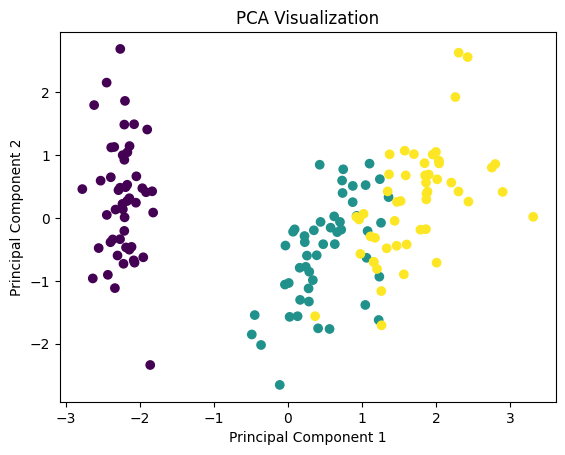

In [ ]:
plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization")

plt.show()

PCA Interpretation

          PCA creates new axes (principal components)

          These capture maximum variance

Helps in:

          Noise reduction

          Faster computation

          Visualization

Part 2: t-SNE Visualization

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_scaled)

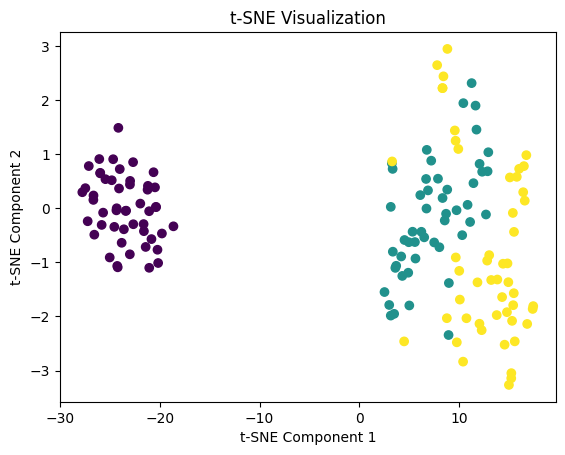

In [ ]:
plt.figure()

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.title("t-SNE Visualization")

plt.show()

t-SNE Interpretation

    Preserves local structure (neighborhoods)

Better at:

      Visualizing complex patterns

      Separating overlapping clusters

      Non-linear technique (unlike PCA)

Combined Insight

In [ ]:
print("PCA retained variance:", sum(pca.explained_variance_ratio_))

PCA retained variance: 0.9581320720000166


# ***`Next Day Practicals:`***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [ ]:
# Load MNIST (handwritten digits)
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

# Use subset for faster computation
X = X[:2000]
y = y[:2000]

print("Shape:", X.shape)

Shape: (2000, 784)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

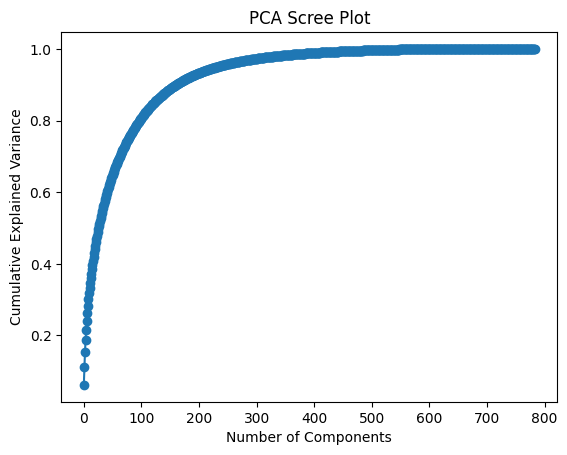

In [ ]:
plt.figure()

explained_variance = pca.explained_variance_ratio_

plt.plot(np.cumsum(explained_variance), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Scree Plot")

plt.show()

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

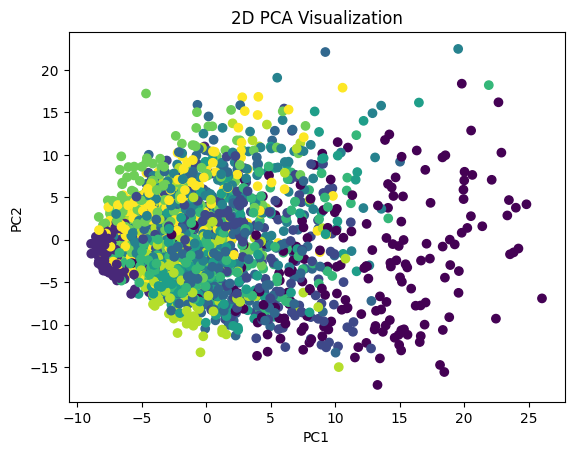

In [ ]:
plt.figure()

plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("2D PCA Visualization")

plt.show()

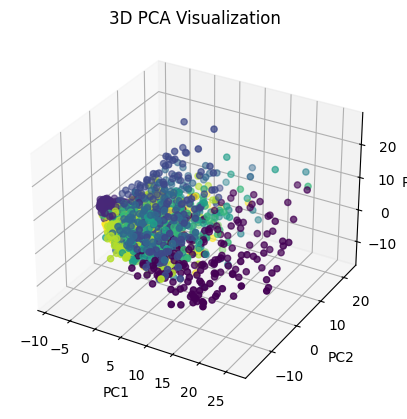

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca_3[:,0], X_pca_3[:,1], X_pca_3[:,2], c=y)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Visualization")

plt.show()

In [ ]:
# Reduce dimensions before clustering
pca_k = PCA(n_components=10)
X_reduced = pca_k.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=10, random_state=42)

clusters = kmeans.fit_predict(X_reduced)

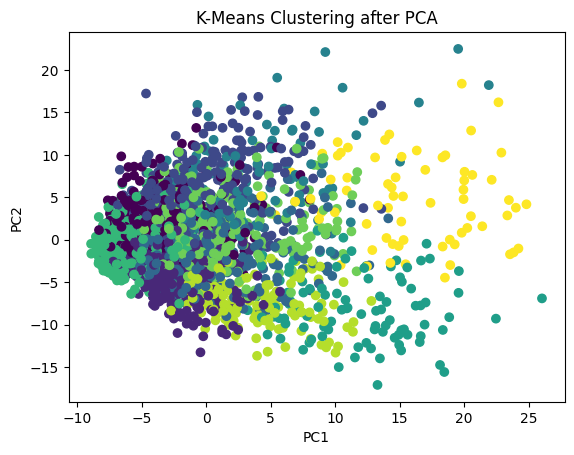

In [ ]:
# Reduce to 2D for plotting
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

plt.figure()

plt.scatter(X_vis[:,0], X_vis[:,1], c=clusters)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("K-Means Clustering after PCA")

plt.show()

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

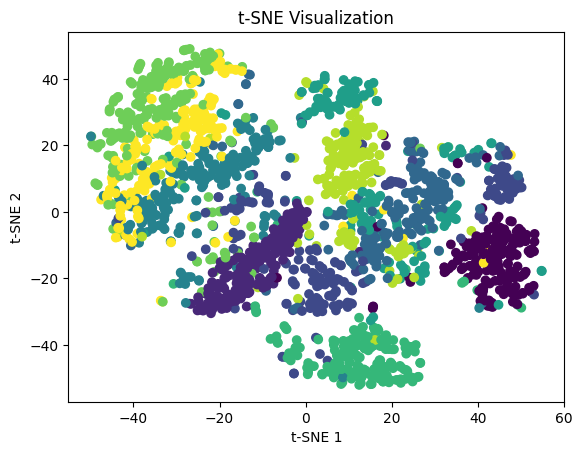

In [ ]:
plt.figure()

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.title("t-SNE Visualization")

plt.show()

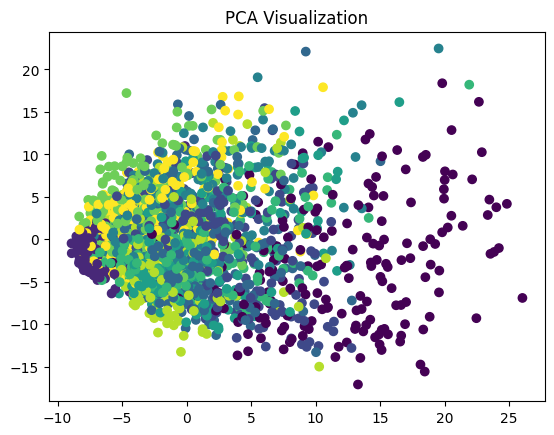

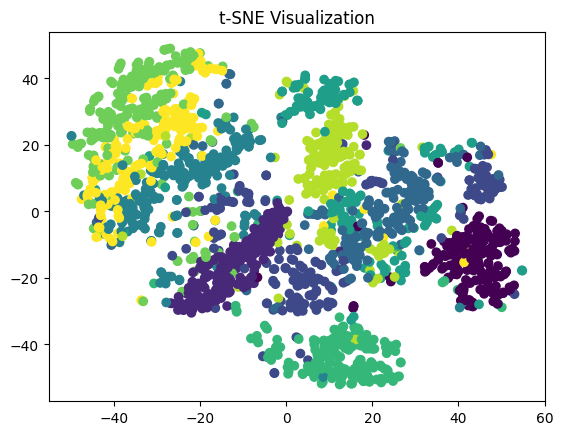

In [ ]:
# PCA plot
plt.figure()

plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y)

plt.title("PCA Visualization")

plt.show()


# t-SNE plot
plt.figure()

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)

plt.title("t-SNE Visualization")

plt.show()

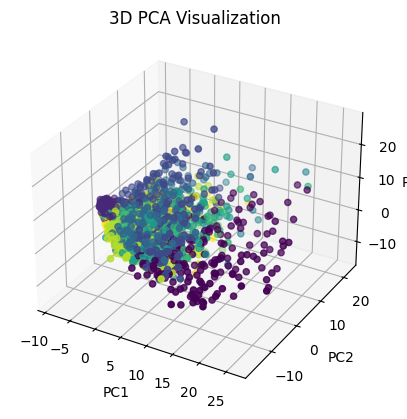

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3 components
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3[:,0],
    X_pca_3[:,1],
    X_pca_3[:,2],
    c=y
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Visualization")

plt.show()

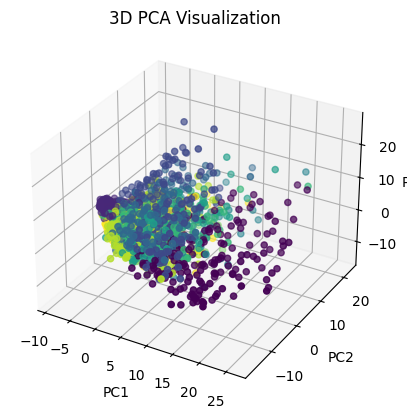

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3 components
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3[:,0],
    X_pca_3[:,1],
    X_pca_3[:,2],
    c=y
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Visualization")

plt.show()

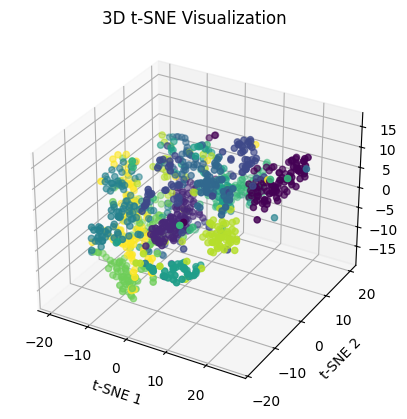

In [ ]:
# Use smaller subset for speed
X_subset = X_scaled[:1000]
y_subset = y[:1000]

tsne_3 = TSNE(n_components=3, perplexity=30, random_state=42)

X_tsne_3 = tsne_3.fit_transform(X_subset)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_tsne_3[:,0],
    X_tsne_3[:,1],
    X_tsne_3[:,2],
    c=y_subset
)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")

plt.title("3D t-SNE Visualization")

plt.show()